<a href="https://colab.research.google.com/github/SergeiVKalinin/spm-reconstruction/blob/main/06_benchmark_radar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Benchmark: RMSE and SSIM across all models and artifact types

Radar plots and summary tables. Minimal code.

In [1]:
# Setup
!git clone https://github.com/SergeiVKalinin/spm-reconstruction.git 2>/dev/null || \
 (cd /content/spm-reconstruction && git pull)
import sys
sys.path.insert(0, '/content/spm-reconstruction')
import importlib, spm_reconstruct
importlib.reload(spm_reconstruct)
print("Models:", list(spm_reconstruct.MODEL_REGISTRY.keys()))

Models: ['(S2, C0, G0, P1)', '(S2, C0, G0, P2)', '(S2, CT, G0, P1)', '(S2, CT, G0, P2)', '(S2, CT, GC, P1)', '(S2, CT, GC, P2)', '(S6, C0, G0, P1)', '(S6, C0, G0, P2)', '(S6, CT, G0, P1)', '(S6, CT, G0, P2)', '(S6, CT, GC, P1)', '(S6, CT, GC, P2)']


## 1. Generate images — one artifact type at a time

In [2]:
import numpy as np
from spm_data import make_scan
from spm_reconstruct import get_model, MODEL_REGISTRY, Evaluator
from spm_eval.metrics import rmse, ssim

ARTIFACTS = ['drift','tip_change','oscillation','crash',
             'scan_line_noise','tip_convolution','streaks','line_jitter']
N         = 6      # images per artifact type
SIZE      = 64     # image size

dataset = {}
for art in ARTIFACTS:
    dataset[art] = [
        make_scan(seed=hash(art)%9999 + i, Ny=SIZE, Nx=SIZE,
                  artifacts=[art], dual_pass=True,
                  surface_type=['sinusoidal','step_terrace','rough'][i%3])
        for i in range(N)]
print(f"Generated {len(ARTIFACTS)*N} images")

Generated 48 images


## 2. Run all 12 models

In [3]:
ev = Evaluator()
MODELS = list(MODEL_REGISTRY.keys())

# rmse_t[model][artifact] and ssim_t[model][artifact] = mean over N images
rmse_t = {m: {} for m in MODELS}
ssim_t = {m: {} for m in MODELS}

for mid in MODELS:
    model = get_model(mid)
    for art in ARTIFACTS:
        recs = [ev.evaluate(model.reconstruct(d), d)
                for d in dataset[art]]
        rmse_t[mid][art] = np.mean([r['rmse'] for r in recs])
        ssim_t[mid][art] = np.mean([r['ssim'] for r in recs])
    print(f"{mid:<26}  mean RMSE={np.mean(list(rmse_t[mid].values())):.4f}")

# Corrupted baselines
rmse_base = {art: np.mean([rmse(d.forward, d.true_surface)
                            for d in dataset[art]]) for art in ARTIFACTS}
ssim_base = {art: np.mean([ssim(d.forward, d.true_surface)
                            for d in dataset[art]]) for art in ARTIFACTS}

(S2, C0, G0, P1)            mean RMSE=0.1023
(S2, C0, G0, P2)            mean RMSE=0.1069
(S2, CT, G0, P1)            mean RMSE=0.0978
(S2, CT, G0, P2)            mean RMSE=0.1143
(S2, CT, GC, P1)            mean RMSE=0.0982
(S2, CT, GC, P2)            mean RMSE=0.1143
(S6, C0, G0, P1)            mean RMSE=0.1007
(S6, C0, G0, P2)            mean RMSE=0.1069
(S6, CT, G0, P1)            mean RMSE=0.0973
(S6, CT, G0, P2)            mean RMSE=0.1132
(S6, CT, GC, P1)            mean RMSE=0.1026
(S6, CT, GC, P2)            mean RMSE=0.1132


## 3. Summary tables

In [4]:
SHORT = [m.replace('(','').replace(')','').replace(' ','') for m in MODELS]

# Sort models by mean RMSE improvement
ranked = sorted(MODELS,
    key=lambda m: -np.mean([100*(rmse_base[a]-rmse_t[m][a])/rmse_base[a]
                             for a in ARTIFACTS]))

art_labels = [a.replace('_',' ') for a in ARTIFACTS]

print("RMSE improvement over corrupted baseline (%)")
print(f"{'Model':<24}", end='')
for a in art_labels: print(f"{a[:8]:>9}", end='')
print(f"{'Mean':>8}")
print("-"*100)
for m in ranked:
    vals = [100*(rmse_base[a]-rmse_t[m][a])/rmse_base[a] for a in ARTIFACTS]
    print(f"{m.replace('(','').replace(')',''):<24}", end='')
    for v in vals: print(f"{v:>+8.1f}%", end='')
    print(f"{np.mean(vals):>+7.1f}%")

print()
print("SSIM improvement over corrupted baseline (%)")
print(f"{'Model':<24}", end='')
for a in art_labels: print(f"{a[:8]:>9}", end='')
print(f"{'Mean':>8}")
print("-"*100)
for m in ranked:
    vals = [100*(ssim_t[m][a]-ssim_base[a])/max(ssim_base[a],0.01)
            for a in ARTIFACTS]
    print(f"{m.replace('(','').replace(')',''):<24}", end='')
    for v in vals: print(f"{v:>+8.1f}%", end='')
    print(f"{np.mean(vals):>+7.1f}%")

RMSE improvement over corrupted baseline (%)
Model                       drift tip chan oscillat    crash scan lin tip conv  streaks line jit    Mean
----------------------------------------------------------------------------------------------------
S6, C0, G0, P1             -28.4%    -4.8%   -95.0%   +29.6%   -51.1%    -1.6%  -156.7%   -76.5%  -48.1%
S6, CT, G0, P1             -33.6%    -7.4%   -99.8%   +55.1%   -52.8%    -1.9%  -170.2%   -76.4%  -48.4%
S2, CT, G0, P1             -35.6%    -8.2%  -100.1%   +54.5%   -51.4%    -3.0%  -178.6%   -74.4%  -49.6%
S2, CT, GC, P1             -35.6%    -8.2%  -100.1%   +52.5%   -51.4%    -3.0%  -178.6%   -74.3%  -49.8%
S6, CT, GC, P1             -33.6%    -7.4%   -99.8%   +28.5%   -52.8%    -1.9%  -170.2%   -76.4%  -51.7%
S2, C0, G0, P1             -34.0%    -5.6%   -97.6%   +31.5%   -55.7%    -2.7%  -182.4%   -76.0%  -52.8%
S2, C0, G0, P2             -22.5%    +0.3%  -130.4%   +33.6%   -66.8%   -17.4%  -243.4%   -82.8%  -66.2%
S6, C0, G0, P2

## 4. Radar plots — RMSE improvement

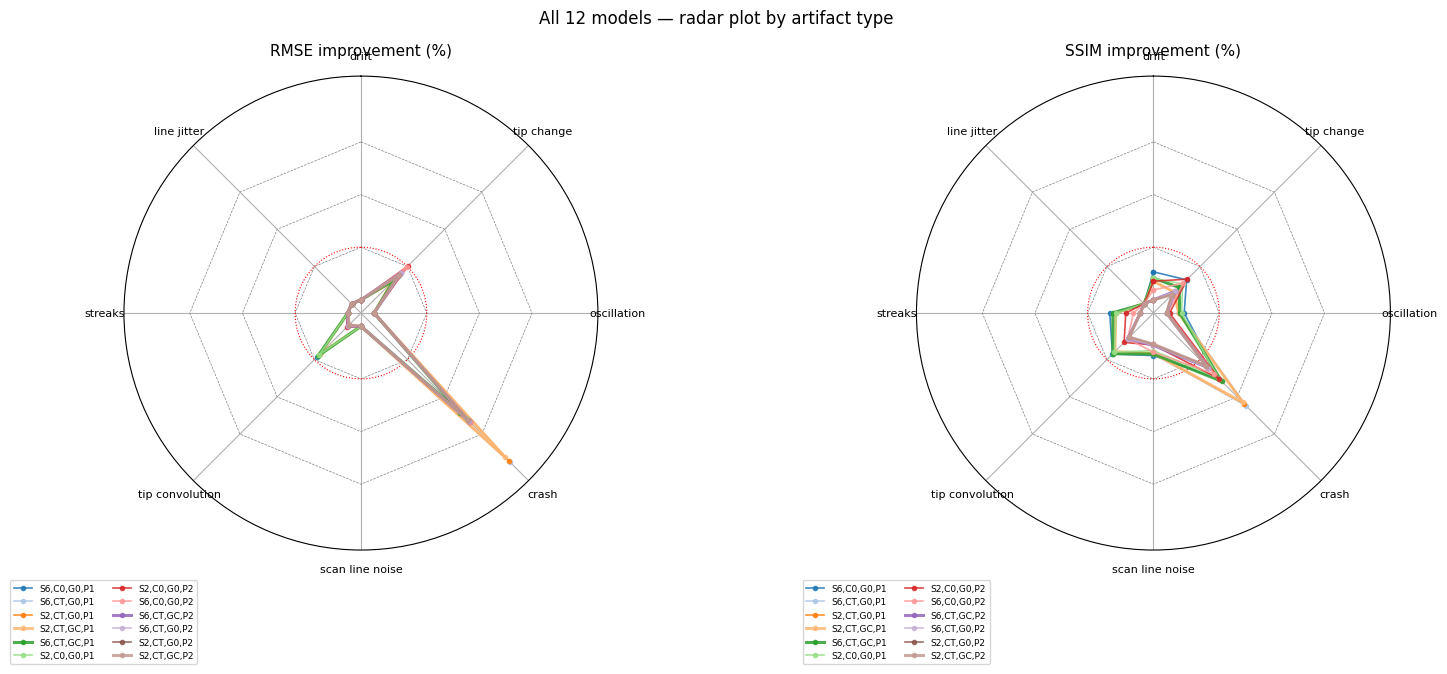

In [5]:
import matplotlib.pyplot as plt

N_AX   = len(ARTIFACTS)
angles = np.linspace(0, 2*np.pi, N_AX, endpoint=False).tolist()
angles += angles[:1]

COLS = plt.cm.tab20.colors   # 20 distinct colours

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         subplot_kw={'polar': True})

for ax, table, base, metric in [
    (axes[0], rmse_t, rmse_base, 'RMSE improvement (%)'),
    (axes[1], ssim_t, ssim_base, 'SSIM improvement (%)'),
]:
    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    for ring in [0, 20, 40]:
        ax.plot(angles, [ring]*(N_AX+1), color='gray', lw=0.5, ls='--')
    ax.axhline(0, color='red', lw=0.8, ls=':')

    for i, m in enumerate(ranked):
        if metric.startswith('RMSE'):
            vals = [np.clip(100*(base[a]-table[m][a])/base[a], -20, 60)
                    for a in ARTIFACTS]
        else:
            vals = [np.clip(100*(table[m][a]-base[a])/max(base[a],0.01),
                            -20, 60) for a in ARTIFACTS]
        vals += vals[:1]
        short = m.replace('(','').replace(')','').replace(' ','')
        lw = 2.2 if 'GC' in m else 1.2
        ax.plot(angles, vals, 'o-', color=COLS[i%20],
                lw=lw, markersize=3, label=short, alpha=0.85)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(art_labels, fontsize=8)
    ax.set_yticks([])
    ax.set_ylim(-25, 65)
    ax.set_title(metric, fontsize=11, pad=15)
    ax.legend(fontsize=6.5, loc='lower left',
              bbox_to_anchor=(-0.25, -0.25), ncol=2)

plt.suptitle('All 12 models — radar plot by artifact type', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Heatmaps — RMSE and SSIM side by side

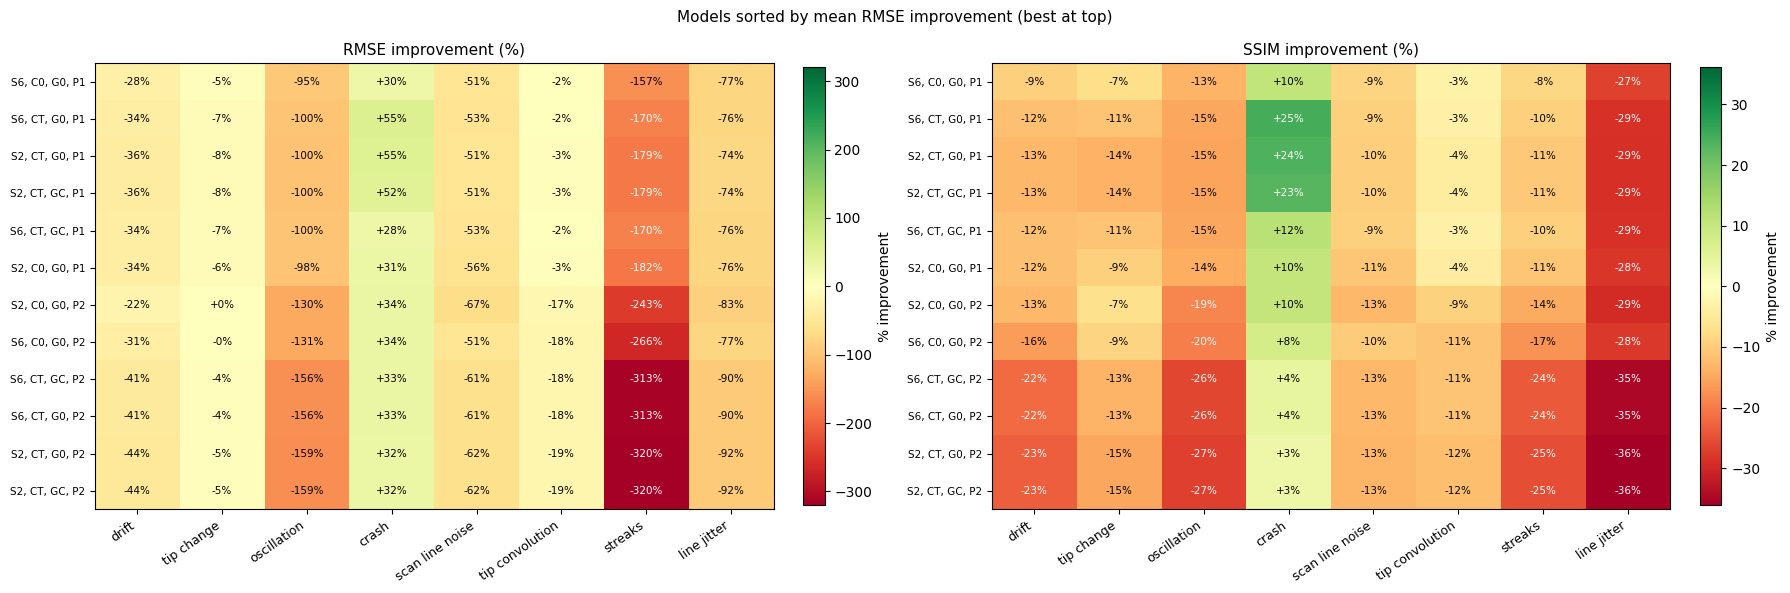

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, table, base, title, better in [
    (axes[0], rmse_t, rmse_base, 'RMSE improvement (%)', True),
    (axes[1], ssim_t, ssim_base, 'SSIM improvement (%)', True),
]:
    data = np.array([
        [100*(base[a] - table[m][a])/base[a]
         if better else
         100*(table[m][a] - base[a])/max(base[a],0.01)
         for a in ARTIFACTS]
        for m in ranked
    ])
    # Fix SSIM: improvement = (ssim_recon - ssim_base) / ssim_base * 100
    if 'SSIM' in title:
        data = np.array([
            [100*(table[m][a] - base[a])/max(base[a],0.01)
             for a in ARTIFACTS]
            for m in ranked])

    v = max(abs(data.max()), abs(data.min()))
    im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=-v, vmax=v)
    for i in range(len(ranked)):
        for j in range(len(ARTIFACTS)):
            tc = 'white' if abs(data[i,j]) > v*0.5 else 'black'
            ax.text(j, i, f'{data[i,j]:+.0f}%',
                    ha='center', va='center', fontsize=7.5, color=tc)
    ax.set_xticks(range(len(ARTIFACTS)))
    ax.set_xticklabels(art_labels, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(ranked)))
    ax.set_yticklabels(
        [m.replace('(','').replace(')','') for m in ranked],
        fontsize=7.5)
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04,
                 label='% improvement')

plt.suptitle('Models sorted by mean RMSE improvement (best at top)',
             fontsize=11)
plt.tight_layout()
plt.show()

## 6. Best model per artifact type

In [7]:
print("Best model per artifact type (by RMSE improvement):\n")
print(f"{'Artifact':<20}  {'Best model':<28}  {'RMSE impr':>10}  {'SSIM impr':>10}")
print("-"*75)
for art in ARTIFACTS:
    best_m = min(MODELS, key=lambda m: rmse_t[m][art])
    ri = 100*(rmse_base[art] - rmse_t[best_m][art])/rmse_base[art]
    si = 100*(ssim_t[best_m][art] - ssim_base[art])/max(ssim_base[art],0.01)
    print(f"{art:<20}  {best_m:<28}  {ri:>+9.1f}%  {si:>+9.1f}%")

Best model per artifact type (by RMSE improvement):

Artifact              Best model                     RMSE impr   SSIM impr
---------------------------------------------------------------------------
drift                 (S2, C0, G0, P2)                  -22.5%      -12.9%
tip_change            (S2, C0, G0, P2)                   +0.3%       -6.8%
oscillation           (S6, C0, G0, P1)                  -95.0%      -13.3%
crash                 (S6, CT, G0, P1)                  +55.1%      +24.8%
scan_line_noise       (S6, C0, G0, P1)                  -51.1%       -8.9%
tip_convolution       (S6, C0, G0, P1)                   -1.6%       -3.0%
streaks               (S6, C0, G0, P1)                 -156.7%       -8.4%
line_jitter           (S2, CT, GC, P1)                  -74.3%      -29.0%


  (S2, C0, G0, P1)
  (S2, C0, G0, P2)
  (S2, CT, G0, P1)
  (S2, CT, G0, P2)
  (S2, CT, GC, P1)
  (S2, CT, GC, P2)
  (S6, C0, G0, P1)
  (S6, C0, G0, P2)
  (S6, CT, G0, P1)
  (S6, CT, G0, P2)
  (S6, CT, GC, P1)
  (S6, CT, GC, P2)
Metrics ready.


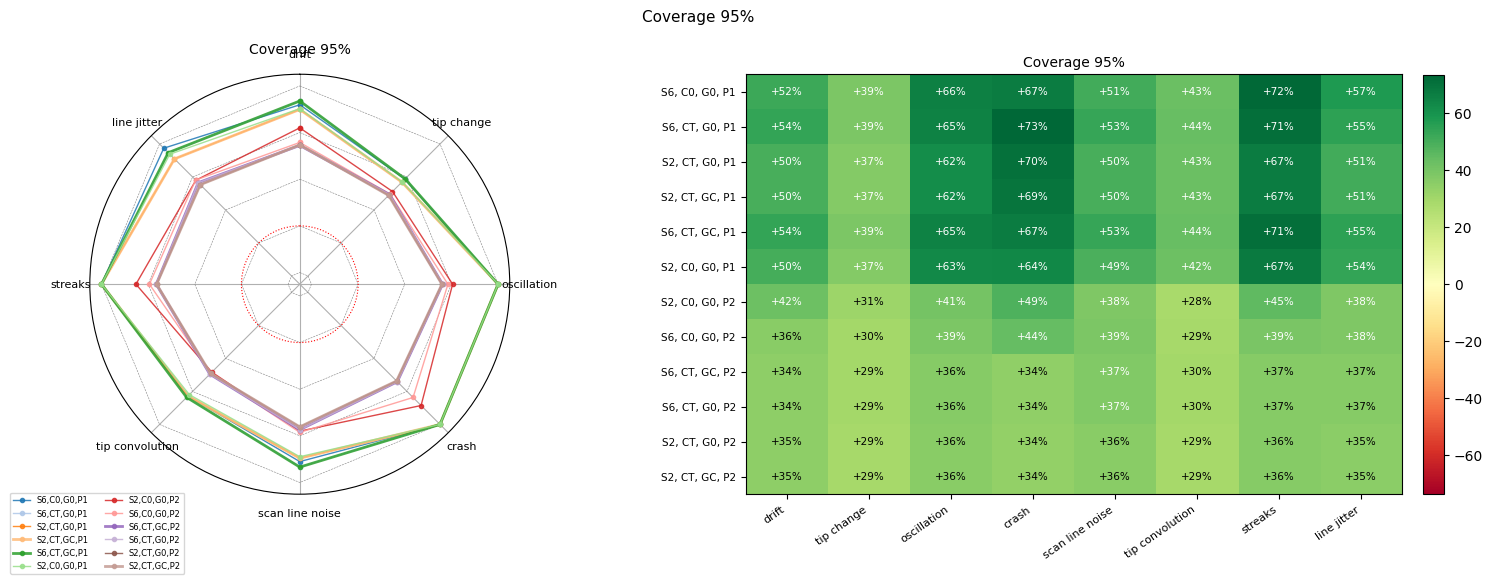

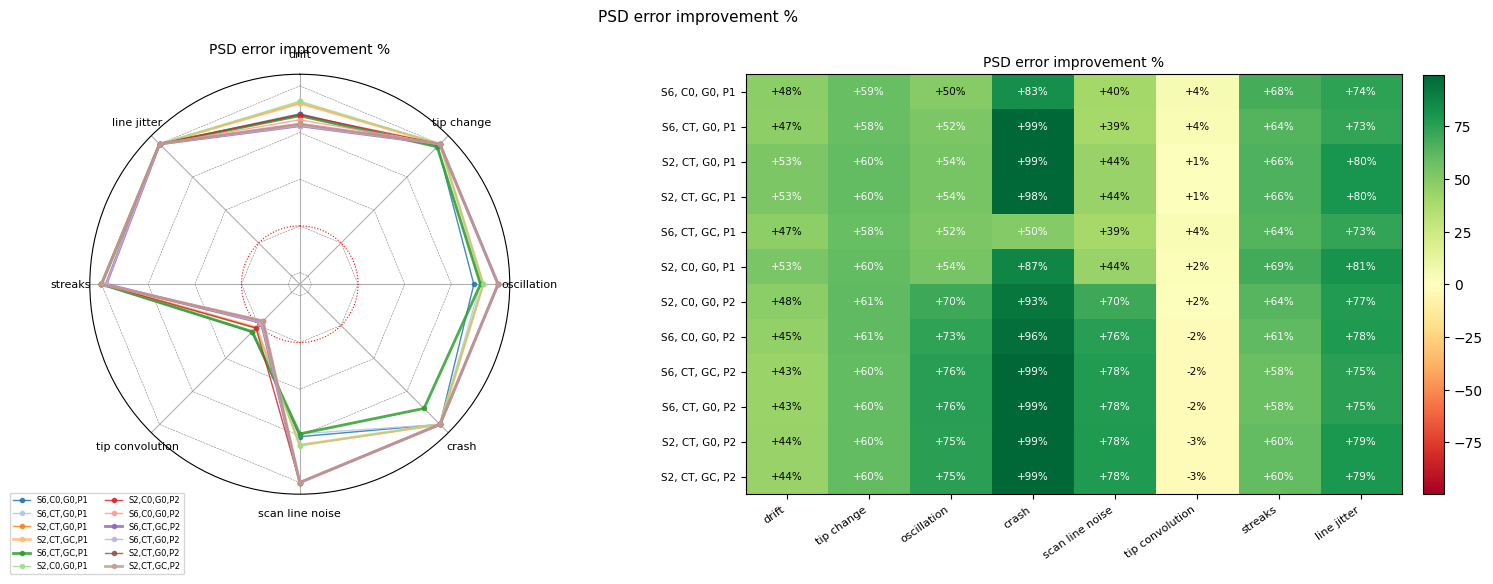

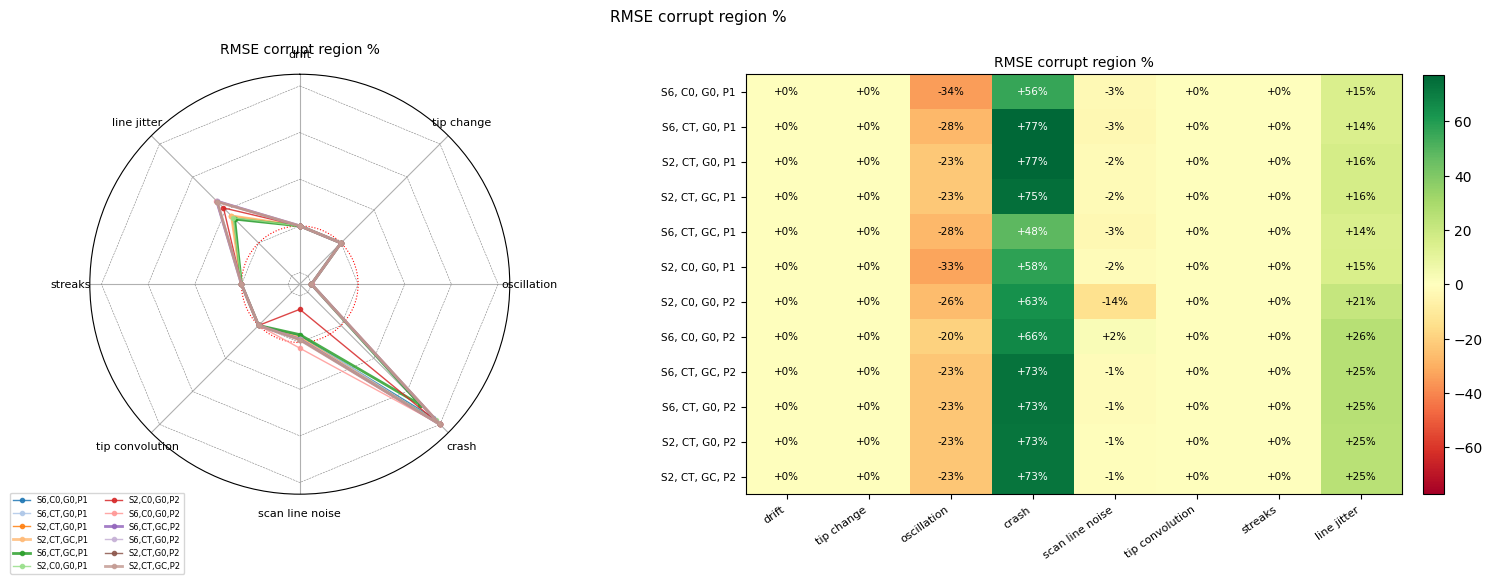

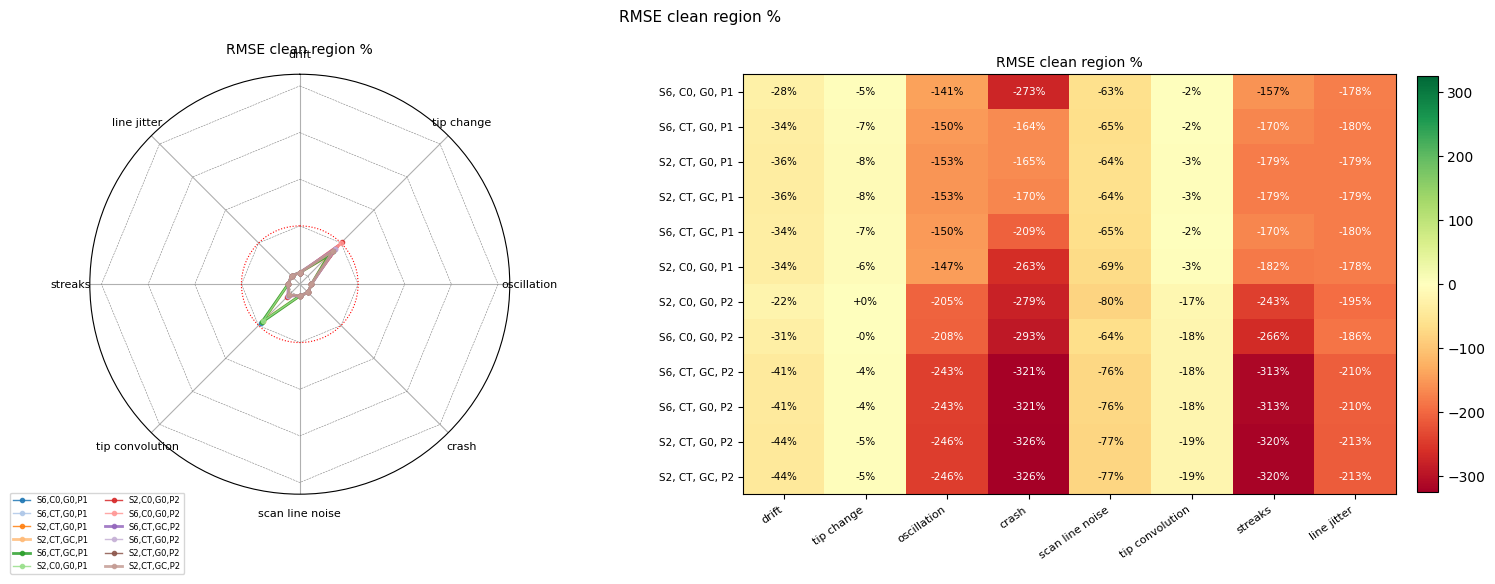


Best and worst reconstruction per model:


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Extra metrics cell — paste into notebook 06 as a new cell
# Requires: dataset, ARTIFACTS, MODELS, ranked, get_model (from earlier cells)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from spm_eval.metrics import coverage, psd_rmse, rmse_by_region, rmse

# ── Compute three new metrics per (model, artifact) ───────────────────────────
cov_t = {m: {} for m in MODELS}   # coverage at 95%
psd_t = {m: {} for m in MODELS}   # PSD error
rcr_t = {m: {} for m in MODELS}   # RMSE in corrupted region
rcl_t = {m: {} for m in MODELS}   # RMSE in clean region

for mid in MODELS:
    model = get_model(mid)
    for art in ARTIFACTS:
        c_v, p_v, rr_v, rl_v = [], [], [], []
        for d in dataset[art]:
            r = model.reconstruct(d)
            c_v.append(coverage(r.reconstructed, r.uncertainty, d.true_surface))
            p_v.append(psd_rmse(r.reconstructed, d.true_surface))
            rr_v.append(rmse_by_region(r.reconstructed, d.true_surface,
                                       d.artifact_mask, threshold=0.5) or 0)
            rl_v.append(rmse_by_region(r.reconstructed, d.true_surface,
                                       1 - d.artifact_mask, threshold=0.5) or 0)
        cov_t[mid][art] = float(np.mean(c_v))
        psd_t[mid][art] = float(np.mean(p_v))
        rcr_t[mid][art] = float(np.mean(rr_v))
        rcl_t[mid][art] = float(np.mean(rl_v))
    print(f"  {mid}")

# Baselines (corrupted input)
cov_base = {art: np.mean([coverage(d.forward,
                                    np.full_like(d.forward, 0.05),
                                    d.true_surface)
                           for d in dataset[art]]) for art in ARTIFACTS}
psd_base = {art: np.mean([psd_rmse(d.forward, d.true_surface)
                           for d in dataset[art]]) for art in ARTIFACTS}
rcr_base = {art: np.mean([rmse_by_region(d.forward, d.true_surface,
                           d.artifact_mask, 0.5) or 0
                           for d in dataset[art]]) for art in ARTIFACTS}
rcl_base = {art: np.mean([rmse_by_region(d.forward, d.true_surface,
                           1 - d.artifact_mask, 0.5) or 0
                           for d in dataset[art]]) for art in ARTIFACTS}
print("Metrics ready.")

# ── Plot helper ───────────────────────────────────────────────────────────────
N_AX   = len(ARTIFACTS)
angles = (np.linspace(0, 2*np.pi, N_AX, endpoint=False).tolist()
          + [np.linspace(0, 2*np.pi, N_AX, endpoint=False)[0]])
labels = [a.replace('_', ' ') for a in ARTIFACTS]
COLS   = plt.cm.tab20.colors

def improvement(tbl, base, m, a):
    return 100 * (base[a] - tbl[m][a]) / max(base[a], 1e-8)

METRICS = [
    ('Coverage 95%',            cov_t,  cov_base,  True),
    ('PSD error improvement %', psd_t,  psd_base,  False),
    ('RMSE corrupt region %',   rcr_t,  rcr_base,  False),
    ('RMSE clean region %',     rcl_t,  rcl_base,  False),
]

for mname, tbl, base, higher in METRICS:
    fig = plt.figure(figsize=(16, 6))
    ax_r = fig.add_subplot(121, polar=True)
    ax_h = fig.add_subplot(122)

    # --- radar ---
    ax_r.set_theta_offset(np.pi / 2)
    ax_r.set_theta_direction(-1)
    for ring in [-20, 0, 20, 40, 60]:
        ax_r.plot(angles, [ring] * (N_AX + 1), color='gray', lw=0.4, ls='--')
    ax_r.axhline(0, color='red', lw=0.8, ls=':')

    for i, m in enumerate(ranked):
        if higher:
            vals = [np.clip(tbl[m][a] * 100, -20, 60) for a in ARTIFACTS]
        else:
            vals = [np.clip(improvement(tbl, base, m, a), -20, 60)
                    for a in ARTIFACTS]
        vals += vals[:1]
        lw = 2.0 if 'GC' in m else 1.0
        ax_r.plot(angles, vals, 'o-', color=COLS[i % 20], lw=lw,
                  markersize=3, alpha=0.85,
                  label=m.replace('(', '').replace(')', '').replace(' ', ''))

    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(labels, fontsize=8)
    ax_r.set_yticks([])
    ax_r.set_ylim(-25, 65)
    ax_r.set_title(mname, fontsize=10, pad=15)
    ax_r.legend(fontsize=6, loc='lower left',
                bbox_to_anchor=(-0.2, -0.2), ncol=2)

    # --- heatmap ---
    if higher:
        data_hm = np.array([[tbl[m][a] * 100 for a in ARTIFACTS]
                             for m in ranked])
    else:
        data_hm = np.array([[improvement(tbl, base, m, a) for a in ARTIFACTS]
                             for m in ranked])
    v = max(abs(data_hm.max()), abs(data_hm.min()))
    im = ax_h.imshow(data_hm, cmap='RdYlGn', aspect='auto', vmin=-v, vmax=v)
    for i in range(len(ranked)):
        for j in range(len(ARTIFACTS)):
            tc = 'white' if abs(data_hm[i, j]) > v * 0.5 else 'black'
            ax_h.text(j, i, f'{data_hm[i, j]:+.0f}%',
                      ha='center', va='center', fontsize=7.5, color=tc)
    ax_h.set_xticks(range(len(ARTIFACTS)))
    ax_h.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    ax_h.set_yticks(range(len(ranked)))
    ax_h.set_yticklabels([m.replace('(', '').replace(')', '')
                           for m in ranked], fontsize=7.5)
    ax_h.set_title(mname, fontsize=10)
    plt.colorbar(im, ax=ax_h, fraction=0.03, pad=0.03)
    plt.suptitle(mname, fontsize=11)
    plt.tight_layout()
    plt.show()

# ── Best and worst image per model ────────────────────────────────────────────
print("\nBest and worst reconstruction per model:")
all_data = [d for art in ARTIFACTS for d in dataset[art]]

fig, axes = plt.subplots(len(ranked), 4, figsize=(14, 2.5 * len(ranked)))
fig.suptitle('Per model — corrupted | best recon | worst recon | error diff\n'
             '(sorted by mean RMSE improvement)', fontsize=9)

for row, mid in enumerate(ranked):
    model  = get_model(mid)
    scores = []
    for d in all_data:
        r  = model.reconstruct(d)
        ri = improvement({'m': {'a': rmse(r.reconstructed, d.true_surface)}},
                         {'a': rmse(d.forward, d.true_surface)}, 'm', 'a')
        scores.append((ri, d, r))
    scores.sort(key=lambda x: -x[0])
    _, bd, br = scores[0]    # best
    _, wd, wr = scores[-1]   # worst

    best_err = np.abs(br.reconstructed - bd.true_surface)
    wrst_err = np.abs(wr.reconstructed - wd.true_surface)
    bi = scores[0][0]; wi = scores[-1][0]

    for col, (img, title, cmap) in enumerate([
        (bd.forward,                f'{mid}\nbest +{bi:.0f}%',  'gray'),
        (br.reconstructed,          'best recon',                'gray'),
        (wr.reconstructed,          f'worst {wi:+.0f}%',        'gray'),
        (best_err - wrst_err,       'blue=best better',          'RdBu_r'),
    ]):
        ax = axes[row, col]
        lim = np.percentile(np.abs(img), 98) if col == 3 else None
        ax.imshow(img, cmap=cmap, origin='upper', aspect='auto',
                  vmin=-lim if lim else None, vmax=lim)
        ax.set_title(title, fontsize=7)
        ax.axis('off')

plt.tight_layout()
plt.show()